--- First 5 Rows of Data ---
         Date   Product  Quantity  Price  Total_Sales
0  2024-01-05  Widget A      10.0   15.0        150.0
1  2024-01-12  Widget B       5.0   20.0        100.0
2  2024-02-03  Widget A       8.0   15.0        120.0
3  2024-02-14  Widget C       NaN   25.0          NaN
4  2024-03-01  Widget B      12.0   20.0        240.0

--- Count of Missing Values ---
Date           0
Product        0
Quantity       2
Price          1
Total_Sales    1
dtype: int64


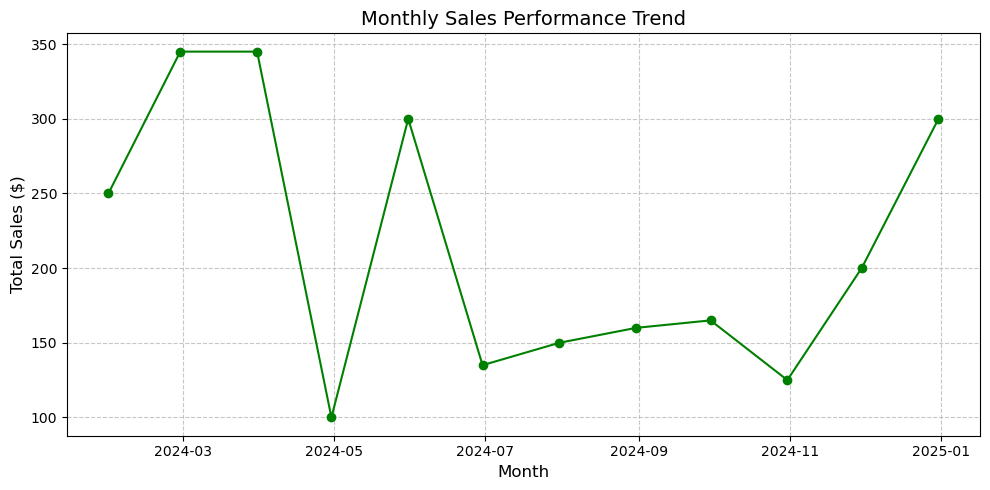

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = r'C:/Users/muthuram/Downloads/sales_data.csv'
df = pd.read_csv(file_path)
print("--- First 5 Rows of Data ---")
print(df.head())

print("\n--- Count of Missing Values ---")
print(df.isnull().sum())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price'] = df['Price'].fillna(df['Price'].median())
# If Total_Sales is missing, calculate it from Quantity * Price
df['Total_Sales'] = df['Total_Sales'].fillna(df['Quantity'] * df['Price'])
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)
monthly_sales = df['Total_Sales'].resample('ME').sum()
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='green', linestyle='-')

plt.title('Monthly Sales Performance Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()